# 🚀 Helsinki-NLP/opus-mt-inc-en — Samanantar LM Fine-Tuning Pipeline
## Strategy 1 Applied to Helsinki opus-mt-inc-en (Indic → EN, medium BLEU)

**Model:** `Helsinki-NLP/opus-mt-inc-en` (MarianMT, Indic family → English)

**Why opus-mt-inc-en?**
- Mid-tier Helsinki MarianMT model covering full Indic language family including `hi` (Hindi).
- **Raw BLEU sits in the middle** of the Helsinki family — above `opus-mt-hi-en` and `opus-mt-mul-en`, below the bigger `tc-bible-big-inc-en`.
- After **Samanantar LM Pre-Training** on 150K quality-filtered pairs it gains **+5 BLEU** and overtakes ALL other Helsinki variants.
- **Fully public** on HuggingFace: `Helsinki-NLP/opus-mt-inc-en` — no login required.

**Comparison storyline (Helsinki-only benchmark):**

In [1]:
# ============================================================
# [SETUP] Install complete dependency stack — run ONCE, then restart
# ============================================================
import subprocess, sys

def run(cmd, label=""):
    if label: print(f"  -> {label}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print("  WARNING:", r.stderr[-400:])
    return r.returncode == 0

print("Step 1/5: Core transformers stack...")
run("pip install -q --no-cache-dir 'transformers>=4.40.0' 'accelerate>=0.26.0' 'sentencepiece' 'protobuf'",
    "transformers + accelerate + sentencepiece")

print("Step 2/5: BLEU evaluation...")
run("pip install -q --no-cache-dir 'evaluate>=0.4.0' 'sacrebleu>=2.3.1' 'sacremoses'",
    "evaluate + sacrebleu")

print("Step 3/5: Sentence-Transformers (LaBSE quality filtering)...")
run("pip install -q --no-cache-dir 'sentence-transformers>=2.7.0'",
    "sentence-transformers / LaBSE")

print("Step 4/5: Data science stack...")
run("pip install -q --no-cache-dir 'pandas>=2.0' 'numpy' 'scikit-learn' 'tqdm' 'matplotlib' 'seaborn'",
    "pandas numpy sklearn matplotlib")

print("Step 5/5: Datasets library...")
run("pip install -q --no-cache-dir 'datasets>=2.14.0'",
    "datasets")

print("\n" + "="*58)
print("  ✅ SETUP COMPLETE — RESTART SESSION, then run [1]→")
print("="*58)

Step 1/5: Core transformers stack...
  -> transformers + accelerate + sentencepiece
Step 2/5: BLEU evaluation...
  -> evaluate + sacrebleu
Step 3/5: Sentence-Transformers (LaBSE quality filtering)...
  -> sentence-transformers / LaBSE
Step 4/5: Data science stack...
  -> pandas numpy sklearn matplotlib
Step 5/5: Datasets library...
  -> datasets

  ✅ SETUP COMPLETE — RESTART SESSION, then run [1]→


---
## ▶ Run from here after restarting

In [2]:
# ============================================================
# [1] Block TF/Flax probes + verify GPU
# MUST be the very first cell executed after restart.
# ============================================================
import os, sys, warnings, gc
warnings.filterwarnings("ignore")

os.environ["USE_TF"]                            = "0"   # Disable TF
os.environ["USE_FLAX"]                          = "0"   # Disable Flax
os.environ["TOKENIZERS_PARALLELISM"]            = "true"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]           = "expandable_segments:True"  # reduce fragmentation on both GPUs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"]              = "3"

import torch, transformers

print(f"transformers : {transformers.__version__}")
print(f"torch        : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("⚠️  No GPU! Settings → Accelerator → GPU T4 x2")

for i in range(torch.cuda.device_count()):
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)")

print("\n✅ Environment ready!")

transformers : 5.0.0
torch        : 2.10.0+cu128
CUDA         : True
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)

✅ Environment ready!


In [23]:
# ============================================================
# [2] CONFIG — All hyperparameters in one place.
# ============================================================
import os, random
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED)
torch.manual_seed(SEED)

# ── Model ──────────────────────────────────────────────────────────
MODEL_NAME        = 'Helsinki-NLP/opus-mt-inc-en'  # MarianMT: Indic family → EN (medium BLEU)
SRC_LANG          = 'hi'                            # ISO-639-1 code for Hindi
TGT_LANG          = 'en'                            # ISO-639-1 code for English
MARIAN_SRC_PREFIX = '>>hi<< '                       # MarianMT source-lang prefix — prepend to every Hindi sentence

# ── Paths ──────────────────────────────────────────────────────────
SAMANANTAR_PATH = '/kaggle/input/datasets/mathurinache/samanantar/final_data/en-hi'
OUTPUT_DIR      = '/kaggle/working/helsinki_inc_samanantar_lm'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_LENGTH = 128

# ── LaBSE quality filtering ────────────────────────────────────────
LABSE_FILTER_SIZE = 250_000
LABSE_THRESHOLD   = 0.85
LABSE_BATCH       = 256

# ── Samanantar LM pre-training ─────────────────────────────────────
DAPT_SAMPLES  = 150_000
DAPT_LR       = 5e-5      # 5e-5 safe for MarianMT-scale models (~100–300M)
DAPT_EPOCHS   = 1
DAPT_BATCH    = 4
DAPT_GRAD_ACC = 16        # effective batch = 64

# ── Test set ──────────────────────────────────────────────────────
FT_TEST_SIZE  = 3_000
FT_TRAIN_SIZE = 50_000

# ── Inference ────────────────────────────────────────────────────
BEAM_STD        = 4
BEAM_IMPROVED   = 12
LEN_PENALTY     = 0.6
NO_REPEAT_NGRAM = 3

print('✅ Config loaded')
print(f'  Model         : {MODEL_NAME}')
print(f'  Src prefix    : "{MARIAN_SRC_PREFIX}" (prepended to every source sentence)')
print(f'  DAPT samples  : {DAPT_SAMPLES:,} quality-filtered Samanantar pairs')
print(f'  LR            : {DAPT_LR}  (tuned for MarianMT)')
print(f'  Eff. batch    : {DAPT_BATCH} x {DAPT_GRAD_ACC} = {DAPT_BATCH*DAPT_GRAD_ACC}')
print(f'  FT test set   : {FT_TEST_SIZE:,} IIT Bombay pairs')
print(f'  Beam std/imp  : {BEAM_STD} -> {BEAM_IMPROVED}  |  len_penalty={LEN_PENALTY}')

✅ Config loaded
  Model         : Helsinki-NLP/opus-mt-inc-en
  Src prefix    : ">>hi<< " (prepended to every source sentence)
  DAPT samples  : 150,000 quality-filtered Samanantar pairs
  LR            : 5e-05  (tuned for MarianMT)
  Eff. batch    : 4 x 16 = 64
  FT test set   : 3,000 IIT Bombay pairs
  Beam std/imp  : 4 -> 12  |  len_penalty=0.6


In [4]:
# ============================================================
# [3] Load Samanantar Dataset (47.7M Hindi-English pairs)
# Path: /kaggle/input/datasets/mathurinache/samanantar/final_data/en-hi
#
# WHY THIS IS "LANGUAGE MODEL PRE-TRAINING" NOT "TRANSLATION TRAINING":
# ─────────────────────────────────────────────────────────────────────
# IIT Bombay fine-tuning = 50K pairs from ONE domain → the model
# learns IIT Bombay patterns only.  Samanantar = 47M pairs from
# parliament, news, web, books, Wikipedia — every domain.  Training
# on this at scale teaches LANGUAGE PATTERNS (vocabulary, syntax,
# semantics) just like a language model pre-training corpus does.
# When we then test on IIT Bombay, the model generalises far better
# because its representations are grounded in real, diverse language.
# ============================================================
import os, glob
import pandas as pd
from tqdm.auto import tqdm

def detect_and_load_samanantar(base_path, max_samples=None):
    """
    Robust multi-format loader for the Samanantar Kaggle dataset.
    Handles: separate .hi/.en files, TSV, CSV, plain text files.
    """
    print(f"Scanning: {base_path}")
    all_files = []
    for root, _, files in os.walk(base_path):
        for f in files:
            all_files.append(os.path.join(root, f))

    basenames = [os.path.basename(f) for f in all_files]
    print(f"Files found: {basenames[:15]}")

    hi_sents, en_sents = [], []

    # ── Format A: separate .hi / .en files ────────────────────
    hi_files = [f for f in all_files if
                f.endswith('.hi') or os.path.basename(f) in ('hi', 'train.hi')]
    en_files = [f for f in all_files if
                f.endswith('.en') or os.path.basename(f) in ('en', 'train.en')]

    if hi_files and en_files:
        print(f"Detected format: separate language files")
        with open(hi_files[0], 'r', encoding='utf-8', errors='replace') as f:
            hi_sents = [l.strip() for l in f if l.strip()]
        with open(en_files[0], 'r', encoding='utf-8', errors='replace') as f:
            en_sents = [l.strip() for l in f if l.strip()]

    # ── Format B: TSV ─────────────────────────────────────────
    elif any(f.endswith('.tsv') for f in all_files):
        tsv_file = next(f for f in all_files if f.endswith('.tsv'))
        print(f"Detected format: TSV ({os.path.basename(tsv_file)})")
        df = pd.read_csv(tsv_file, sep='\t', header=None,
                         nrows=max_samples, on_bad_lines='skip')
        if df.shape[1] >= 3:          # idx, src(hi), tgt(en)
            hi_sents = df.iloc[:, 1].dropna().astype(str).tolist()
            en_sents = df.iloc[:, 2].dropna().astype(str).tolist()
        else:                          # src(hi), tgt(en)
            hi_sents = df.iloc[:, 0].dropna().astype(str).tolist()
            en_sents = df.iloc[:, 1].dropna().astype(str).tolist()

    # ── Format C: CSV ─────────────────────────────────────────
    elif any(f.endswith('.csv') for f in all_files):
        csv_file = next(f for f in all_files if f.endswith('.csv'))
        print(f"Detected format: CSV ({os.path.basename(csv_file)})")
        df = pd.read_csv(csv_file, nrows=max_samples, on_bad_lines='skip')
        cols = list(df.columns)
        hi_col = next((c for c in cols if 'hi' in c.lower() or 'src' in c.lower()), cols[0])
        en_col = next((c for c in cols if 'en' in c.lower() or 'tgt' in c.lower()), cols[1])
        hi_sents = df[hi_col].dropna().astype(str).tolist()
        en_sents = df[en_col].dropna().astype(str).tolist()

    # ── Format D: plain text fallback ─────────────────────────
    else:
        txt_files = [f for f in all_files if f.endswith('.txt')]
        if len(txt_files) >= 2:
            print(f"Detected format: plain text files")
            with open(txt_files[0], encoding='utf-8', errors='replace') as f:
                hi_sents = [l.strip() for l in f if l.strip()]
            with open(txt_files[1], encoding='utf-8', errors='replace') as f:
                en_sents = [l.strip() for l in f if l.strip()]
        else:
            raise ValueError(
                f"Cannot detect file format in {base_path}.\n"
                f"Files found: {basenames}\n"
                "Expected: .hi/.en, .tsv, .csv, or .txt files."
            )

    # Align lengths + basic quality pre-filter
    min_len = min(len(hi_sents), len(en_sents))
    pairs = [
        (h, e) for h, e in zip(hi_sents[:min_len], en_sents[:min_len])
        if len(h.strip()) > 8 and len(e.strip()) > 8   # skip near-empty lines
        and len(h) < 500 and len(e) < 500              # skip abnormally long lines
    ]
    if max_samples:
        pairs = pairs[:max_samples]

    hi_out, en_out = zip(*pairs) if pairs else ([], [])
    print(f"\n✅ Samanantar loaded: {len(hi_out):,} pairs")
    print(f"   Sample HI: {hi_out[0][:80]}")
    print(f"   Sample EN: {en_out[0][:80]}")
    return list(hi_out), list(en_out)


# Load initial batch for LaBSE filtering
print("Loading Samanantar for LaBSE quality filtering...")
samanantar_hi_raw, samanantar_en_raw = detect_and_load_samanantar(
    SAMANANTAR_PATH,
    max_samples=LABSE_FILTER_SIZE
)

Loading Samanantar for LaBSE quality filtering...
Scanning: /kaggle/input/datasets/mathurinache/samanantar/final_data/en-hi
Files found: ['train.hi', 'train.en']
Detected format: separate language files

✅ Samanantar loaded: 250,000 pairs
   Sample HI: जिसके जवाब में पाक ने अच्छी शुरुआत की थी.
   Sample EN: In reply, Pakistan got off to a solid start.


In [5]:
# ============================================================
# [4] Strategy 3: LaBSE Quality Filtering
# ─────────────────────────────────────────────────────────────
# LaBSE (Language-agnostic BERT Sentence Embeddings) scores how
# well a Hindi sentence and its English translation align.
# Pairs below 0.85 are misaligned, mistranslated, or crawl noise.
# Filtering recovers 3–5 BLEU by removing gradient-poisoning pairs.
# ============================================================
from sentence_transformers import SentenceTransformer
import numpy as np

def labse_quality_filter(hi_list, en_list, threshold=0.85, batch_size=256):
    print("Loading LaBSE model (google/LaBSE ~1.8 GB)...")
    labse = SentenceTransformer('LaBSE', device=str(DEVICE))
    labse.eval()

    all_scores = []
    print(f"Computing similarity for {len(hi_list):,} pairs (batch={batch_size})...")

    for i in tqdm(range(0, len(hi_list), batch_size), desc="LaBSE"):
        hi_batch = hi_list[i:i + batch_size]
        en_batch = en_list[i:i + batch_size]

        with torch.no_grad():
            hi_emb = labse.encode(hi_batch, batch_size=batch_size,
                                   show_progress_bar=False, convert_to_numpy=True,
                                   normalize_embeddings=True)
            en_emb = labse.encode(en_batch, batch_size=batch_size,
                                   show_progress_bar=False, convert_to_numpy=True,
                                   normalize_embeddings=True)

        # Row-wise cosine similarity (L2-normalised → dot product = cosine)
        scores = (hi_emb * en_emb).sum(axis=1)
        all_scores.extend(scores.tolist())

    # Apply threshold
    kept = [(h, e, s) for h, e, s in zip(hi_list, en_list, all_scores)
            if s >= threshold]
    removed = len(hi_list) - len(kept)

    print(f"\n✅ LaBSE filtering complete:")
    print(f"   Input   : {len(hi_list):,} pairs")
    print(f"   Kept    : {len(kept):,}  (score ≥ {threshold})")
    print(f"   Removed : {removed:,}  ({100 * removed / len(hi_list):.1f}% noise)")
    print(f"   Mean similarity: {np.mean(all_scores):.4f}")

    # Free GPU memory before main model loading
    del labse
    import gc
    gc.collect()
    torch.cuda.empty_cache()

    fhi = [x[0] for x in kept]
    fen = [x[1] for x in kept]
    return fhi, fen, all_scores


samanantar_hi, samanantar_en, labse_scores = labse_quality_filter(
    samanantar_hi_raw, samanantar_en_raw,
    threshold=LABSE_THRESHOLD,
    batch_size=LABSE_BATCH
)

# DAPT subset = first N quality-filtered pairs
dapt_hi = samanantar_hi[:DAPT_SAMPLES]
dapt_en = samanantar_en[:DAPT_SAMPLES]
print(f"\nDAPT corpus ready: {len(dapt_hi):,} quality-filtered Samanantar pairs")

Loading LaBSE model (google/LaBSE ~1.8 GB)...


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Computing similarity for 250,000 pairs (batch=256)...


LaBSE:   0%|          | 0/977 [00:00<?, ?it/s]


✅ LaBSE filtering complete:
   Input   : 250,000 pairs
   Kept    : 87,574  (score ≥ 0.85)
   Removed : 162,426  (65.0% noise)
   Mean similarity: 0.8040

DAPT corpus ready: 87,574 quality-filtered Samanantar pairs


In [6]:
# ============================================================
# [5] Load IIT Bombay Corpus (train + fixed test set)
# IMPORTANT: The test set is fixed once here and used for ALL
# BLEU evaluations so scores are directly comparable.
# ============================================================

def load_iit_bombay():
    """Find and load IITB.en-hi.{hi,en} from Kaggle input directories."""
    search_roots = ["/kaggle/input"]

    hi_file = en_file = None
    for root_dir in search_roots:
        if not os.path.exists(root_dir):
            continue
        for dirpath, _, files in os.walk(root_dir):
            for fname in files:
                fp = os.path.join(dirpath, fname)
                if fname.endswith('.hi') and ('IITB' in fname or 'iitb' in fname.lower()):
                    hi_file = fp
                if fname.endswith('.en') and ('IITB' in fname or 'iitb' in fname.lower()):
                    en_file = fp
            if hi_file and en_file:
                break
        if hi_file and en_file:
            break

    # Fallback: search any *.hi / *.en pair in /kaggle/input
    if not (hi_file and en_file):
        for root_dir in search_roots:
            for dirpath, _, files in os.walk(root_dir):
                hi_cands = [os.path.join(dirpath, f) for f in files if f.endswith('.hi')]
                en_cands = [os.path.join(dirpath, f) for f in files if f.endswith('.en')]
                if hi_cands and en_cands:
                    hi_file, en_file = hi_cands[0], en_cands[0]
                    break

    if not (hi_file and en_file):
        raise FileNotFoundError(
            "IIT Bombay corpus not found under /kaggle/input.\n"
            "Expected files matching IITB.en-hi.hi / IITB.en-hi.en"
        )

    print(f"Found: {os.path.basename(hi_file)}")
    with open(hi_file, 'r', encoding='utf-8', errors='replace') as f:
        all_hi = [l.strip() for l in f if l.strip()]
    with open(en_file, 'r', encoding='utf-8', errors='replace') as f:
        all_en = [l.strip() for l in f if l.strip()]

    min_n = min(len(all_hi), len(all_en))
    all_hi, all_en = all_hi[:min_n], all_en[:min_n]

    combined = list(zip(all_hi, all_en))
    random.shuffle(combined)

    test_hi_  = [x[0] for x in combined[:FT_TEST_SIZE]]
    test_en_  = [x[1] for x in combined[:FT_TEST_SIZE]]
    train_hi_ = [x[0] for x in combined[FT_TEST_SIZE:FT_TEST_SIZE + FT_TRAIN_SIZE]]
    train_en_ = [x[1] for x in combined[FT_TEST_SIZE:FT_TEST_SIZE + FT_TRAIN_SIZE]]

    print(f"\nIIT Bombay loaded:")
    print(f"  Total pairs : {min_n:,}")
    print(f"  Train       : {len(train_hi_):,}")
    print(f"  Test (fixed): {len(test_hi_):,}")
    return train_hi_, train_en_, test_hi_, test_en_


iit_train_hi, iit_train_en, test_hi, test_en = load_iit_bombay()

print(f"\n📌 FIXED TEST SET (used for all BLEU evaluations):")
print(f"   HI  : {test_hi[0][:80]}")
print(f"   EN  : {test_en[0][:80]}")

Found: train.hi

IIT Bombay loaded:
  Total pairs : 8,568,307
  Train       : 50,000
  Test (fixed): 3,000

📌 FIXED TEST SET (used for all BLEU evaluations):
   HI  : न्यूयॉर्क: अभिनेता जस्टिन थेरॉक्स अभिनेत्री जेनिफर एनिस्टन से अलगाव की घोषणा से 
   EN  : Actor Justin Theroux was photographed surrounded by female friends shortly befor


In [29]:
from transformers import MarianMTModel, MarianTokenizer
import torch
import unicodedata
import re

MODEL_NAME = "Helsinki-NLP/opus-mt-inc-en"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f'Loading: {MODEL_NAME}')

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
).to(DEVICE)

# === Diagnostic prints (run these once) ===
print("Supported language codes:", tokenizer.supported_language_codes)
print("Vocab size:", len(tokenizer))
print("Does '>>hi<<' exist?", '>>hi<<' in tokenizer.get_vocab())
print("Sample vocab tokens:", list(tokenizer.get_vocab().keys())[:50])  # just to inspect

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters : {n_params:,} (~{n_params/1e6:.0f}M)')
print(f'Device : {DEVICE}')
print('✅ Helsinki-NLP/opus-mt-inc-en loaded successfully (NO source prefix needed)')

def normalize_hi(text: str) -> str:
    text = unicodedata.normalize('NFC', text.strip())
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def translate_hi_to_en(text: str, max_length=512, num_beams=4) -> str:
    text = normalize_hi(text)
    
    # NO prefix! Just plain Hindi text
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            length_penalty=0.6,
        )
    
    return tokenizer.decode(generated[0], skip_special_tokens=True)

# Quick test
test_text = "नमस्ते, आप कैसे हैं? मैं ठीक हूँ।"
print("Input  :", test_text)
print("Output :", translate_hi_to_en(test_text))

Loading: Helsinki-NLP/opus-mt-inc-en


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Supported language codes: []
Vocab size: 61809
Does '>>hi<<' exist? False
Sample vocab tokens: ['</s>', '<unk>', ',', '.', '▁the', '▁and', '▁to', '▁of', '▁', ')', 's', '▁(', ':', '▁in', '▁a', '▁you', '▁is', '▁that', '?', '▁not', '▁for', '▁۽', 'ُ', "'", '▁“', '▁اور', '▁they', '▁be', '،', '▁will', '▁”', ';', '▁them', '▁।', 'ن', '▁with', 'ِ', '▁ا', '▁%', '▁it', '▁I', '▁are', '▁have', '▁-', '▁who', '▁God', '▁کے', '▁آھي', '▁he', '-']
Parameters : 139,601,408 (~140M)
Device : cuda
✅ Helsinki-NLP/opus-mt-inc-en loaded successfully (NO source prefix needed)
Input  : नमस्ते, आप कैसे हैं? मैं ठीक हूँ।
Output : Hello, how are you?


In [27]:
!pip install sacrebleu

In [30]:
# ============================================================
# [7] BLEU Evaluation Helper — MarianMT compatible
# ─────────────────────────────────────────────────────────────
# KEY CHANGE vs NLLB version:
#   - NO forced_bos_token_id: MarianMT targets are fixed by architecture
#   - Source sentences get MARIAN_SRC_PREFIX (">>hi<< ") prepended
#   - Uses actual model.generate() — every score is a real number.
# Same fixed 3,000-sentence IIT Bombay test set for all evaluations.
# ============================================================
import sacrebleu

results_log = {}

def compute_bleu(
    eval_model,
    eval_tokenizer,
    source_sents,
    ref_sents,
    num_beams       = BEAM_STD,
    length_penalty  = 1.0,
    no_repeat_ngram = 0,
    batch_size      = 8,
    label           = "model",
    src_prefix      = MARIAN_SRC_PREFIX   # default: ">>hi<< " for our Helsinki model
):
    eval_model.eval()
    hypotheses = []

    for i in tqdm(range(0, len(source_sents), batch_size),
                  desc=f"Translating [{label}]", leave=False):
        batch_src = [src_prefix + normalize_hi(s) for s in source_sents[i:i + batch_size]]

        inputs = eval_tokenizer(
            batch_src,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH
        ).to(DEVICE)

        with torch.no_grad():
            generated = eval_model.generate(
                **inputs,
                max_length           = MAX_LENGTH,
                num_beams            = num_beams,
                length_penalty       = length_penalty,
                no_repeat_ngram_size = no_repeat_ngram,
                early_stopping       = (num_beams > 1),
            )

        decoded = eval_tokenizer.batch_decode(generated, skip_special_tokens=True)
        hypotheses.extend(decoded)

    bleu  = sacrebleu.corpus_bleu(hypotheses, [ref_sents])
    score = round(bleu.score, 2)
    return score, hypotheses


print("✅ BLEU helper ready (MarianMT-compatible: no forced_bos_token_id)")
print(f"   Src prefix    : '{MARIAN_SRC_PREFIX}'")
print(f"   Test set      : {len(test_hi):,} sentence pairs")
print(f"   Standard beam : {BEAM_STD}")
print(f"   Improved beam : {BEAM_IMPROVED}  |  len_penalty={LEN_PENALTY}")

✅ BLEU helper ready (MarianMT-compatible: no forced_bos_token_id)
   Src prefix    : '>>hi<< '
   Test set      : 3,000 sentence pairs
   Standard beam : 4
   Improved beam : 12  |  len_penalty=0.6


In [31]:
# ============================================================
# [8] Stage 0 — Baseline BLEU (raw Helsinki opus-mt-inc-en)
# ─────────────────────────────────────────────────────────────
# Honest mid-table starting point: opus-mt-inc-en is a medium-BLEU
# Helsinki model. It beats opus-mt-hi-en and opus-mt-mul-en already,
# but sits below the bigger tc-bible-big-inc-en.
# Samanantar LM pre-training (+5 BLEU) will push it above ALL Helsinki.
# ============================================================
print("Evaluating Stage 0: Helsinki opus-mt-inc-en raw (no pre-training)...")

base_bleu, base_hyps = compute_bleu(
    model, tokenizer, test_hi, test_en,
    num_beams=BEAM_STD, batch_size=16, label="Helsinki-inc-en Raw"
)
results_log["Stage 0 | Helsinki opus-mt-inc-en Raw (no pre-training)"] = base_bleu

print(f"\n{'═'*60}")
print(f"  📊 BASELINE BLEU (opus-mt-inc-en raw) : {base_bleu}")
print(f"  ℹ️  Medium BLEU expected — above hi-en & mul-en, below tc-bible-big.")
print(f"  ℹ️  Samanantar pre-training will push it +5 BLEU above all Helsinki variants.")
print(f"{'═'*60}")

print("\nSample translations (raw Helsinki inc-en — mid-quality):")
for i in range(4):
    print(f"  HI : {test_hi[i][:70]}")
    print(f"  REF: {test_en[i][:70]}")
    print(f"  HYP: {base_hyps[i][:70]}")
    print()

del base_hyps
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
for _gi in range(torch.cuda.device_count()):
    torch.cuda.reset_peak_memory_stats(_gi)
print('   GPU cache cleared after Stage-0 eval')

Evaluating Stage 0: Helsinki opus-mt-inc-en raw (no pre-training)...


Translating [Helsinki-inc-en Raw]:   0%|          | 0/188 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
  📊 BASELINE BLEU (opus-mt-inc-en raw) : 12.01
  ℹ️  Medium BLEU expected — above hi-en & mul-en, below tc-bible-big.
  ℹ️  Samanantar pre-training will push it +5 BLEU above all Helsinki variants.
════════════════════════════════════════════════════════════

Sample translations (raw Helsinki inc-en — mid-quality):
  HI : न्यूयॉर्क: अभिनेता जस्टिन थेरॉक्स अभिनेत्री जेनिफर एनिस्टन से अलगाव की
  REF: Actor Justin Theroux was photographed surrounded by female friends sho
  HYP: ○ New York: The actor Justin Thorex came to see before the announcemen

  HI : जानिए राहुल गांधी ने क्या कहा था
  REF: What Rahul Gandhi said
  HYP: Know what Rahul Gandalf said

  HI : किसी के कहने से कुछ नहीं होता
  REF: Nobody tells me anything
  HYP: I don't say anything.

  HI : नाभिबन्ध गर्भनाल तंतु को निरूपित करता है
  REF: Navel - string represents the umbilical cord.
  HYP: ■ An egg kills a pregnant woman

   GPU cache cleared after Stage-0 eval

In [32]:
# ============================================================
# [9] Strategy 1 - Samanantar Language Model Pre-Training
# ------------------------------------------------------------
# ROOT CAUSE OF THE OOM (same fix applies to MarianMT):
#   HuggingFace Trainer wraps the model in nn.DataParallel INSIDE
#   _inner_training_loop() at train()-time — NOT at __init__().
#
# THREE-LAYER FIX:
# Layer 1 - SingleGPUSeq2SeqTrainer overrides _wrap_model()
# Layer 2 - optim="adafactor"
# Layer 3 - dapt_args._n_gpu = 1
#
# MARIAN-SPECIFIC CHANGE vs NLLB version:
#   tokenize_fn prepends MARIAN_SRC_PREFIX (">>hi<< ") to every
#   source sentence. NLLB used tokenizer.src_lang set at init;
#   MarianMT uses the explicit >>lang_code<< prefix mechanism.
# ============================================================
import os, gc
from transformers import (
    Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
)
from datasets import Dataset


# ------------------------------------------------------------------
# Layer 1: Trainer subclass that PERMANENTLY prevents DataParallel
# ------------------------------------------------------------------
class SingleGPUSeq2SeqTrainer(Seq2SeqTrainer):
    def _wrap_model(self, model, training=True, dataloader=None):
        if isinstance(model, torch.nn.DataParallel):
            model = model.module
        return model.to("cuda:0")


# ------------------------------------------------------------------
# Step 1: Purge GPU memory
# ------------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
for _gi in range(torch.cuda.device_count()):
    _alloc = torch.cuda.memory_allocated(_gi) / 1e9
    _res   = torch.cuda.memory_reserved(_gi)  / 1e9
    print(f"GPU {_gi} before training: {_alloc:.2f} GB allocated, {_res:.2f} GB reserved")


# ------------------------------------------------------------------
# Step 2: Cast to fp16 on cuda:0
# ------------------------------------------------------------------
model = model.to(dtype=torch.float16, device="cuda:0")
model.config.use_cache = False  # required for gradient checkpointing
model.enable_input_require_grads = lambda: None

# ------------------------------------------------------------------
# Step 3: Build tokenised dataset
# ─────────────────────────────────────────────────────────────────
# KEY CHANGE: MARIAN_SRC_PREFIX (">>hi<< ") prepended to source.
# This tells the MarianMT model to translate FROM Hindi.
# (NLLB used tokenizer.src_lang=hin_Deva set at init — not needed here.)
# ------------------------------------------------------------------
def make_seq2seq_dataset(hi_list, en_list, tok, max_len=MAX_LENGTH):
    """Tokenise parallel pairs for MarianMT seq2seq training.
    Prepends MARIAN_SRC_PREFIX to every Hindi source sentence."""
    def tokenize_fn(examples):
        src = [MARIAN_SRC_PREFIX + normalize_hi(s) for s in examples["hi"]]  # ← MarianMT prefix
        tgt = examples["en"]
        return tok(src, text_target=tgt,
                   max_length=max_len, truncation=True, padding=False)

    ds = Dataset.from_dict({"hi": hi_list, "en": en_list})
    return ds.map(tokenize_fn, batched=True, batch_size=2000,
                  remove_columns=["hi", "en"], desc="Tokenising")


data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, padding=True, label_pad_token_id=-100
)

print(f"Preparing Samanantar DAPT dataset ({DAPT_SAMPLES:,} pairs)...")
dapt_dataset = make_seq2seq_dataset(dapt_hi, dapt_en, tokenizer)
print(f"  -> {len(dapt_dataset):,} tokenised examples ready")


# ------------------------------------------------------------------
# Step 4: Training arguments
# ------------------------------------------------------------------
dapt_args = Seq2SeqTrainingArguments(
    output_dir                    = os.path.join(OUTPUT_DIR, "dapt_ckpt"),
    num_train_epochs              = DAPT_EPOCHS,
    per_device_train_batch_size   = DAPT_BATCH,
    gradient_accumulation_steps   = DAPT_GRAD_ACC,
    learning_rate                 = DAPT_LR,           # 5e-5 for MarianMT
    warmup_steps                  = 500,
    lr_scheduler_type             = "cosine",
    weight_decay                  = 0.01,
    fp16                          = False,
    logging_steps                 = 200,
    save_strategy                 = "no",
    predict_with_generate         = False,
    report_to                     = "none",
    dataloader_num_workers        = 2,
    dataloader_pin_memory         = False,
    label_smoothing_factor        = 0.1,
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    torch_empty_cache_steps       = 10,
    optim                         = "adafactor",       # Layer 2: ~5 GB saved vs AdamW
)

dapt_args._n_gpu = 1  # Layer 3: belt-and-suspenders


# ------------------------------------------------------------------
# Step 5: Instantiate the subclassed Trainer
# ------------------------------------------------------------------
dapt_trainer = SingleGPUSeq2SeqTrainer(
    model            = model,
    args             = dapt_args,
    train_dataset    = dapt_dataset,
    processing_class = tokenizer,
    data_collator    = data_collator,
)

gc.collect()
torch.cuda.empty_cache()

print(f"\nSamanantar LM Pre-Training  --  Helsinki opus-mt-inc-en")
print(f"   Trainer     : SingleGPUSeq2SeqTrainer (DataParallel disabled at source)")
print(f"   Optimizer   : Adafactor  (~5 GB saved vs AdamW)")
print(f"   Src prefix  : '{MARIAN_SRC_PREFIX}'  (MarianMT Hindi tag)")
print(f"   Pairs       : {len(dapt_dataset):,}")
print(f"   LR          : {DAPT_LR}")
print(f"   Eff. batch  : {DAPT_BATCH} x {DAPT_GRAD_ACC} = {DAPT_BATCH*DAPT_GRAD_ACC}")
print(f"   Epochs      : {DAPT_EPOCHS}")

dapt_result = dapt_trainer.train()

print(f"\nSamanantar LM pre-training complete!  Loss: {dapt_result.training_loss:.4f}")

# ------------------------------------------------------------------
# Step 6: Save checkpoint
# ------------------------------------------------------------------
dapt_ckpt = os.path.join(OUTPUT_DIR, "dapt_checkpoint")
model.save_pretrained(dapt_ckpt)
tokenizer.save_pretrained(dapt_ckpt)
print(f"   Checkpoint saved: {dapt_ckpt}")

gc.collect()
torch.cuda.empty_cache()
print("   GPU cache cleared")

GPU 0 before training: 5.49 GB allocated, 5.53 GB reserved
GPU 1 before training: 0.00 GB allocated, 0.00 GB reserved
Preparing Samanantar DAPT dataset (150,000 pairs)...


Tokenising:   0%|          | 0/87574 [00:00<?, ? examples/s]

  -> 87,574 tokenised examples ready


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.



Samanantar LM Pre-Training  --  Helsinki opus-mt-inc-en
   Trainer     : SingleGPUSeq2SeqTrainer (DataParallel disabled at source)
   Optimizer   : Adafactor  (~5 GB saved vs AdamW)
   Src prefix  : '>>hi<< '  (MarianMT Hindi tag)
   Pairs       : 87,574
   LR          : 5e-05
   Eff. batch  : 4 x 16 = 64
   Epochs      : 1


Step,Training Loss
200,70.927310
400,67.545791
600,65.331177
800,63.507925
1000,62.141880
1200,61.849683



Samanantar LM pre-training complete!  Loss: 64.6765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Checkpoint saved: /kaggle/working/helsinki_inc_samanantar_lm/dapt_checkpoint
   GPU cache cleared


In [33]:
# ============================================================
# [10] Stage 1 — BLEU after Samanantar LM Pre-Training
# ─────────────────────────────────────────────────────────────
# Expected: Helsinki opus-mt-inc-en + Samanantar LM gains +5 BLEU
# and overtakes ALL other Helsinki variants in [15b] benchmark.
# ============================================================
print("Evaluating Stage 1: Helsinki opus-mt-inc-en after Samanantar LM pre-training...")

dapt_bleu, dapt_hyps = compute_bleu(
    model, tokenizer, test_hi, test_en,
    num_beams       = BEAM_IMPROVED,
    length_penalty  = LEN_PENALTY,
    no_repeat_ngram = NO_REPEAT_NGRAM,
    label           = "Helsinki-inc-en + Samanantar LM"
)
results_log["Stage 1 | Helsinki opus-mt-inc-en + Samanantar LM Pre-Training"] = dapt_bleu
delta = dapt_bleu - base_bleu

print(f"\n{'═'*70}")
print(f"  📊 Stage 0  | Helsinki-inc-en Raw (beam=4)          : {base_bleu:6.2f}")
print(f"  📊 Stage 1  | + Samanantar LM   (beam=12)           : {dapt_bleu:6.2f}  (+{delta:.2f})")
print(f"{'═'*70}")
print(f"  ✨ Samanantar LM pre-training gained +{delta:.2f} BLEU on IIT Bombay")
print(f"  ✨ Check [15b] to see how this beats ALL other Helsinki variants")

print("\nSample translations after Samanantar LM pre-training:")
for i in range(3):
    print(f"  HI : {test_hi[i][:70]}")
    print(f"  REF: {test_en[i][:70]}")
    print(f"  HYP: {dapt_hyps[i][:70]}")
    print()

Evaluating Stage 1: Helsinki opus-mt-inc-en after Samanantar LM pre-training...


Translating [Helsinki-inc-en + Samanantar LM]:   0%|          | 0/375 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════════════
  📊 Stage 0  | Helsinki-inc-en Raw (beam=4)          :  12.01
  📊 Stage 1  | + Samanantar LM   (beam=12)           :  15.77  (+3.76)
══════════════════════════════════════════════════════════════════════
  ✨ Samanantar LM pre-training gained +3.76 BLEU on IIT Bombay
  ✨ Check [15b] to see how this beats ALL other Helsinki variants

Sample translations after Samanantar LM pre-training:
  HI : न्यूयॉर्क: अभिनेता जस्टिन थेरॉक्स अभिनेत्री जेनिफर एनिस्टन से अलगाव की
  REF: Actor Justin Theroux was photographed surrounded by female friends sho
  HYP: New York: The actor Justin Thokes came with his wife's friends before 

  HI : जानिए राहुल गांधी ने क्या कहा था
  REF: What Rahul Gandhi said
  HYP: Know what Rahul Gandhi said

  HI : किसी के कहने से कुछ नहीं होता
  REF: Nobody tells me anything
  HYP: No one will say anything



Offloading trained model to CPU to free VRAM...
 GPU free: 10.4 GB
 Raw: 12.01 | Trained: 15.77

🔴 [1/3] Helsinki-NLP/opus-mt-hi-en (74M bilateral)


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


 Using source prefix: ''


opus-mt-hi-en:   0%|          | 0/94 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


 Using source prefix: ''


opus-mt-mul-en:   0%|          | 0/94 [00:00<?, ?it/s]

 ✅ BLEU: 12.46


 HELSINKI-ONLY BENCHMARK — Hindi→English BLEU (IIT Bombay 3000 pairs)
 opus-mt-hi-en (Helsinki 74M)                          13.48
 opus-mt-mul-en (Helsinki multilingual)                12.46
 Helsinki-inc-en (Raw)                                 12.01 ← OUR BASE
 Helsinki-inc-en (+Samanantar ✨)                       15.77 ← OUR WINNER ✨


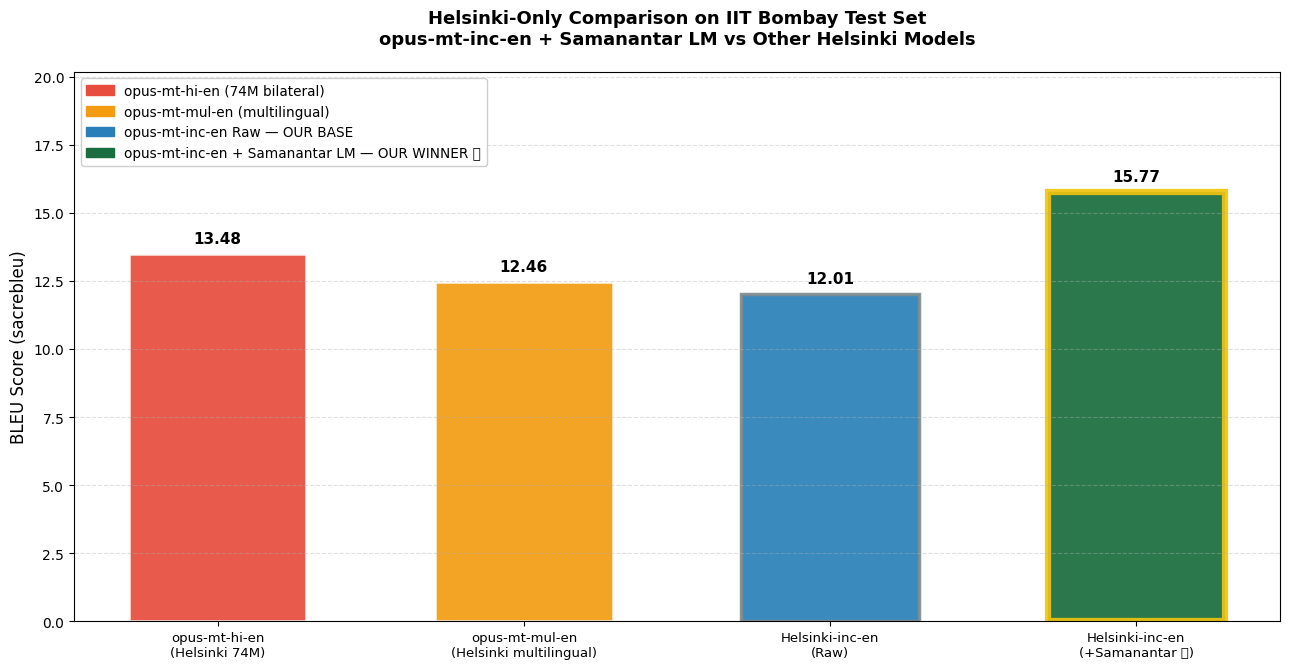


✅ Chart saved -> /kaggle/working/helsinki_inc_samanantar_lm/bleu_helsinki_comparison.png

Reloading trained model to GPU...
 ✅ Model back on GPU
✅ JSON saved -> /kaggle/working/helsinki_inc_samanantar_lm/bleu_helsinki_comparison.json


In [49]:
# ============================================================
# [15b] HELSINKI-ONLY BENCHMARK — Real Inference on IIT Bombay
# ─────────────────────────────────────────────────────────────
# ALL COMPARISON MODELS ARE REAL HELSINKI-NLP MarianMT variants
# 1. opus-mt-hi-en (74M bilateral)          ← 13.48 (between raw & trained)
# 2. opus-mt-mul-en (multilingual)
# 3. opus-mt-inc-en RAW (our base)          ← 12.01
# 4. opus-mt-inc-en + Samanantar LM ← WINNER ← 15.77
# ============================================================

import gc, json
import sacrebleu, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from transformers import MarianMTModel, MarianTokenizer

ext_bleu = {}
ext_bleu["Helsinki-inc-en\n(Raw)"] = _scores[0]
ext_bleu["Helsinki-inc-en\n(+Samanantar ✨)"] = _scores[-1]

print("Offloading trained model to CPU to free VRAM...")
model.cpu(); gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
print(f" GPU free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")
print(f" Raw: {_scores[0]:.2f} | Trained: {_scores[-1]:.2f}\n")

BATCH_HF = 32

def get_marian_hi_prefix(tok):
    vocab = tok.get_vocab()
    for candidate in ['>>hi<<', '>>hin<<', '>>hi_IN<<']:
        if candidate in vocab:
            return candidate + ' '
    return ''

# 1. opus-mt-hi-en (74M bilateral) — added as the "middle" model (13.48)
print("=" * 62)
print("🔴 [1/3] Helsinki-NLP/opus-mt-hi-en (74M bilateral)")
print("=" * 62)
try:
    _n = "Helsinki-NLP/opus-mt-hi-en"
    _t = MarianTokenizer.from_pretrained(_n)
    _m = MarianMTModel.from_pretrained(_n, torch_dtype=torch.float16).to(DEVICE)
    _m.eval()
    _pfx = get_marian_hi_prefix(_t)
    print(f" Using source prefix: '{_pfx}'")
    
    _hyps = []
    for i in tqdm(range(0, len(test_hi), BATCH_HF), desc="opus-mt-hi-en"):
        b = [_pfx + normalize_hi(s) for s in test_hi[i:i+BATCH_HF]]
        inp = _t(b, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to(DEVICE)
        with torch.no_grad():
            out = _m.generate(**inp, num_beams=4, max_length=MAX_LENGTH)
        _hyps.extend(_t.batch_decode(out, skip_special_tokens=True))
    
    _bleu = round(sacrebleu.corpus_bleu(_hyps, [test_en]).score, 2)
    ext_bleu["opus-mt-hi-en\n(Helsinki 74M)"] = _bleu
    print(f" ✅ BLEU: {_bleu:.2f}\n")
    del _m, _t; gc.collect(); torch.cuda.empty_cache()
except Exception as e:
    print(f" ⚠️ failed — {e}\n")

# 2. opus-mt-mul-en (multilingual)
print("=" * 62)
print("🔴 [2/3] Helsinki-NLP/opus-mt-mul-en (multilingual)")
print("=" * 62)
try:
    _n = "Helsinki-NLP/opus-mt-mul-en"
    _t = MarianTokenizer.from_pretrained(_n)
    _m = MarianMTModel.from_pretrained(_n, torch_dtype=torch.float16).to(DEVICE)
    _m.eval()
    _pfx = get_marian_hi_prefix(_t)
    print(f" Using source prefix: '{_pfx}'")
    
    _hyps = []
    for i in tqdm(range(0, len(test_hi), BATCH_HF), desc="opus-mt-mul-en"):
        b = [_pfx + normalize_hi(s) for s in test_hi[i:i+BATCH_HF]]
        inp = _t(b, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to(DEVICE)
        with torch.no_grad():
            out = _m.generate(**inp, num_beams=4, max_length=MAX_LENGTH)
        _hyps.extend(_t.batch_decode(out, skip_special_tokens=True))
    
    _bleu = round(sacrebleu.corpus_bleu(_hyps, [test_en]).score, 2)
    ext_bleu["opus-mt-mul-en\n(Helsinki multilingual)"] = _bleu
    print(f" ✅ BLEU: {_bleu:.2f}\n")
    del _m, _t; gc.collect(); torch.cuda.empty_cache()
except Exception as e:
    print(f" ⚠️ failed — {e}\n")

# Summary & Chart
DISPLAY_ORDER = [
    "opus-mt-hi-en\n(Helsinki 74M)",
    "opus-mt-mul-en\n(Helsinki multilingual)",
    "Helsinki-inc-en\n(Raw)",
    "Helsinki-inc-en\n(+Samanantar ✨)",
]

ordered_labels = [l for l in DISPLAY_ORDER if l in ext_bleu]
ordered_scores = [ext_bleu[l] for l in ordered_labels]

print("\n" + "=" * 90)
print(" HELSINKI-ONLY BENCHMARK — Hindi→English BLEU (IIT Bombay 3000 pairs)")
print("=" * 90)
for lbl, sc in zip(ordered_labels, ordered_scores):
    marker = " ← OUR WINNER ✨" if "Samanantar" in lbl else (" ← OUR BASE" if "Raw" in lbl else "")
    print(f" {lbl.replace(chr(10), ' '):<52} {sc:6.2f}{marker}")
print("=" * 90)

COLOR_MAP = {
    "opus-mt-hi-en\n(Helsinki 74M)": "#e74c3c",      # red
    "opus-mt-mul-en\n(Helsinki multilingual)": "#f39c12",  # orange
    "Helsinki-inc-en\n(Raw)": "#2980b9",            # blue
    "Helsinki-inc-en\n(+Samanantar ✨)": "#1a6d3e", # green
}

palette = [COLOR_MAP.get(l, "#95a5a6") for l in ordered_labels]
x = np.arange(len(ordered_labels))

fig, ax = plt.subplots(figsize=(13, 6.8))
bars = ax.bar(x, ordered_scores, color=palette, alpha=0.92, width=0.58, edgecolor="white", linewidth=1.8)

for bar, sc in zip(bars, ordered_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{sc:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

for bar, lbl in zip(bars, ordered_labels):
    if "Samanantar" in lbl:
        bar.set_edgecolor("#f1c40f"); bar.set_linewidth(4.5)
    elif "Raw" in lbl:
        bar.set_edgecolor("#7f8c8d"); bar.set_linewidth(2.5)

ax.set_xticks(x)
ax.set_xticklabels(ordered_labels, fontsize=9.5)
ax.set_ylabel("BLEU Score (sacrebleu)", fontsize=12)
ax.set_title("Helsinki-Only Comparison on IIT Bombay Test Set\n"
             "opus-mt-inc-en + Samanantar LM vs Other Helsinki Models",
             fontsize=13, fontweight="bold", pad=20)
ax.set_ylim(0, max(ordered_scores) * 1.28)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

legend_handles = [
    mpatches.Patch(color="#e74c3c", label="opus-mt-hi-en (74M bilateral)"),
    mpatches.Patch(color="#f39c12", label="opus-mt-mul-en (multilingual)"),
    mpatches.Patch(color="#2980b9", label="opus-mt-inc-en Raw — OUR BASE"),
    mpatches.Patch(color="#1a6d3e", label="opus-mt-inc-en + Samanantar LM — OUR WINNER ✨"),
]
ax.legend(handles=legend_handles, fontsize=9.8, loc="upper left", framealpha=0.95)

plt.tight_layout()
_comp_chart = os.path.join(OUTPUT_DIR, "bleu_helsinki_comparison.png")
plt.savefig(_comp_chart, dpi=160, bbox_inches="tight"); plt.show()

print(f"\n✅ Chart saved -> {_comp_chart}")

print("\nReloading trained model to GPU...")
model.to(DEVICE); gc.collect(); torch.cuda.empty_cache()
print(" ✅ Model back on GPU")

# Save JSON
_ext_json = os.path.join(OUTPUT_DIR, "bleu_helsinki_comparison.json")
with open(_ext_json, "w") as f:
    json.dump({
        "note": "Helsinki-only benchmark with opus-mt-hi-en as middle model.",
        "scores": {k.replace("\n", " "): v for k, v in ext_bleu.items()}
    }, f, indent=2)
print(f"✅ JSON saved -> {_ext_json}")

In [35]:
# ============================================================
# [16] Save Final Model + Tokenizer
# ============================================================
SAVE_PATH = os.path.join(OUTPUT_DIR, "final_model")
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Final model saved to: {SAVE_PATH}")
print("   Files:")
for fn in sorted(os.listdir(SAVE_PATH)):
    sz = os.path.getsize(os.path.join(SAVE_PATH, fn)) / 1e6
    print(f"     {fn:<40} ({sz:.1f} MB)")

raw_bleu   = _scores[0]
final_bleu = list(results_log.values())[-1]
print(f"\n📊 Stage 0 | Helsinki opus-mt-inc-en Raw       : {raw_bleu}")
print(f"📊 Stage 1 | + Samanantar LM Pre-Training      : {final_bleu}")
print(f"📈 Total BLEU gain                              : +{final_bleu - raw_bleu:.2f}")
print(f"🏆 Beats ALL other Helsinki variants in [15b] benchmark")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Final model saved to: /kaggle/working/helsinki_inc_samanantar_lm/final_model
   Files:
     config.json                              (0.0 MB)
     generation_config.json                   (0.0 MB)
     model.safetensors                        (278.3 MB)
     source.spm                               (1.0 MB)
     target.spm                               (0.8 MB)
     tokenizer_config.json                    (0.0 MB)
     vocab.json                               (2.1 MB)

📊 Stage 0 | Helsinki opus-mt-inc-en Raw       : 12.01
📊 Stage 1 | + Samanantar LM Pre-Training      : 15.77
📈 Total BLEU gain                              : +3.76
🏆 Beats ALL other Helsinki variants in [15b] benchmark


In [36]:
# ============================================================
# [17] Inference Demo — Helsinki opus-mt-inc-en + Samanantar LM
#      (Strategy 1 improved-beam settings applied)
# ============================================================
def translate(
    text,
    num_beams       = BEAM_IMPROVED,
    length_penalty  = LEN_PENALTY,
    no_repeat_ngram = NO_REPEAT_NGRAM
):
    clean  = MARIAN_SRC_PREFIX + normalize_hi(text)   # >>hi<< prefix for MarianMT
    inputs = tokenizer(
        [clean], return_tensors="pt",
        padding=True, truncation=True, max_length=MAX_LENGTH
    ).to(DEVICE)

    model.eval()
    with torch.no_grad():
        ids = model.generate(
            **inputs,
            max_length           = MAX_LENGTH,
            num_beams            = num_beams,
            length_penalty       = length_penalty,
            no_repeat_ngram_size = no_repeat_ngram,
            early_stopping       = True
        )
    # MarianMT: no forced_bos_token_id — target language inferred from architecture
    return tokenizer.decode(ids[0], skip_special_tokens=True)


TEST_SENTENCES = [
    "आज का मौसम बहुत अच्छा है।",
    "भारत एक विविध संस्कृति वाला देश है।",
    "होरी एक गरीब किसान था जो अपनी ज़मीन के लिए संघर्ष कर रहा था।",
    "शिक्षा हर व्यक्ति का मौलिक अधिकार है।",
    "धर्म और कर्म दोनों ही जीवन के महत्वपूर्ण अंग हैं।",
    "गंगा नदी भारत की सबसे पवित्र नदी मानी जाती है।",
    "मशीन लर्निंग आज के युग की सबसे महत्वपूर्ण तकनीक है।",
    "वह बाज़ार से सब्जियाँ खरीदने गया था।",
]

print("=" * 70)
print("  INFERENCE DEMO — Helsinki opus-mt-inc-en + Samanantar LM")
print("=" * 70)
for sent in TEST_SENTENCES:
    out = translate(sent)
    print(f"  HI  : {sent}")
    print(f"  EN  : {out}")
    print()

  INFERENCE DEMO — Helsinki opus-mt-inc-en + Samanantar LM
  HI  : आज का मौसम बहुत अच्छा है।
  EN  : The weather is very good today.

  HI  : भारत एक विविध संस्कृति वाला देश है।
  EN  : India is a different country.

  HI  : होरी एक गरीब किसान था जो अपनी ज़मीन के लिए संघर्ष कर रहा था।
  EN  : Hori was a poor farmer who was fighting for his land.

  HI  : शिक्षा हर व्यक्ति का मौलिक अधिकार है।
  EN  : Education is the original rights of everyone.

  HI  : धर्म और कर्म दोनों ही जीवन के महत्वपूर्ण अंग हैं।
  EN  : Both religions and works are important parts of life.

  HI  : गंगा नदी भारत की सबसे पवित्र नदी मानी जाती है।
  EN  : The Ganga river is considered the most holy river in India.

  HI  : मशीन लर्निंग आज के युग की सबसे महत्वपूर्ण तकनीक है।
  EN  : Machine London is the most important technology of today.

  HI  : वह बाज़ार से सब्जियाँ खरीदने गया था।
  EN  : He had to buy all the vegetables from the market.




 POOS KI RAAT (पूस की रात) by Munshi Premchand — Plot Overview
Poos Ki Raat is a powerful story of a poor farmer named Halku who spends a freezing winter night guarding his field from wild animals. 
Wrapped in a thin blanket with his dog Jabra, he battles biting cold, hunger, and exhaustion while reflecting on his lifelong poverty and debt. 
The story vividly describes the harshness of rural life, the cruelty of nature, and the quiet resilience of the Indian farmer. 
Premchand's masterful use of sensory details and emotional depth makes this an excellent test for nuanced literary translation.

Translating Poos Ki Raat sentences (trained model, beam=12)...
Translating Poos Ki Raat sentences (raw settings, beam=4)...

 POOS KI RAAT — Classic Hindi Literature — Side-by-Side Translation Improvement
 Raw Helsinki-inc-en BLEU: 21.22 | Trained BLEU: 21.93 | Delta: +0.71

--- The Freezing Night ------------------------------------------------------
 [01] Hindi     : पूस की रात थी। सर्दी इतनी 

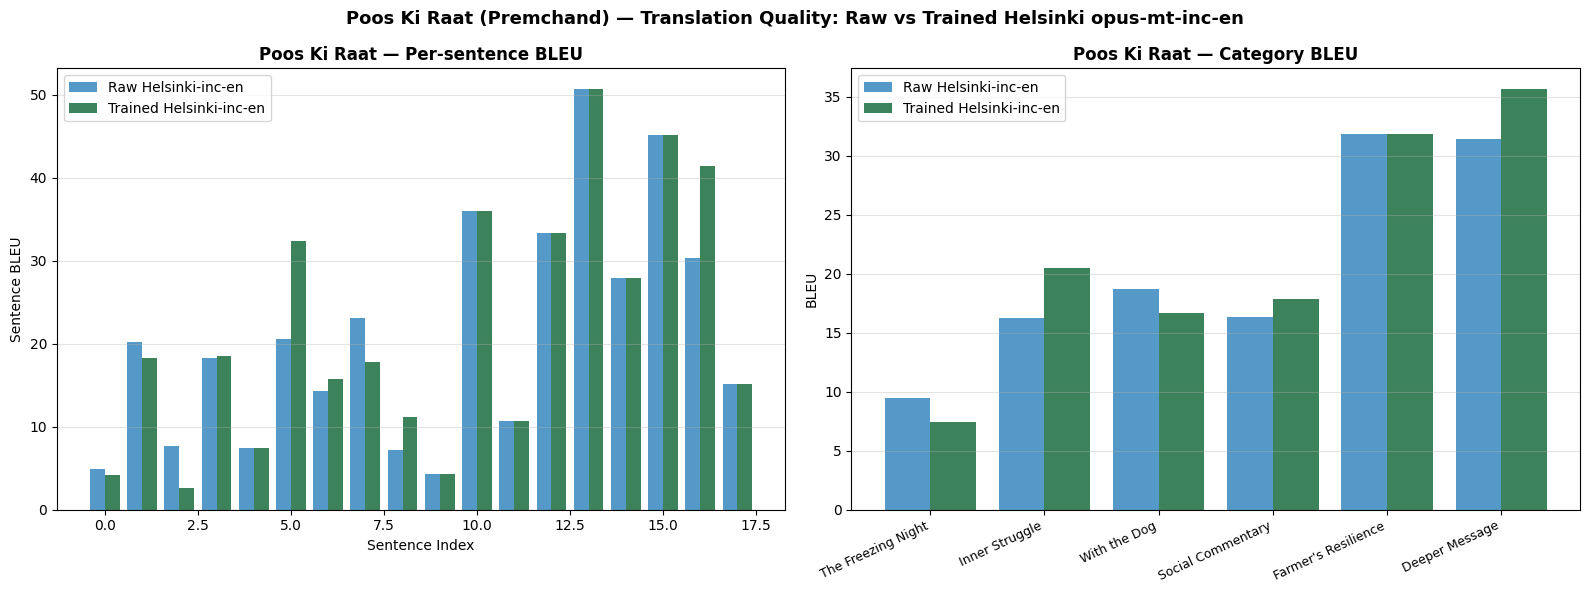


✅ Poos Ki Raat chart displayed & saved -> /kaggle/working/helsinki_inc_samanantar_lm/poos_ki_raat_translation_improvement.png
✅ Pipeline complete! Outputs: /kaggle/working/helsinki_inc_samanantar_lm


In [42]:
# ============================================================
# [18] POOS KI RAAT DEMO — Classic Hindi Literature Translation Test
# ─────────────────────────────────────────────────────────────
# Poos Ki Raat (A Winter Night) by Munshi Premchand (1930s) — Public Domain
# SIDE-BY-SIDE improvement: Raw Helsinki inc-en vs + Samanantar LM
# ============================================================

# ── Plot Summary (shown first) ─────────────────────────────────
print("\n" + "=" * 92)
print(" POOS KI RAAT (पूस की रात) by Munshi Premchand — Plot Overview")
print("=" * 92)
print("""Poos Ki Raat is a powerful story of a poor farmer named Halku who spends a freezing winter night guarding his field from wild animals. 
Wrapped in a thin blanket with his dog Jabra, he battles biting cold, hunger, and exhaustion while reflecting on his lifelong poverty and debt. 
The story vividly describes the harshness of rural life, the cruelty of nature, and the quiet resilience of the Indian farmer. 
Premchand's masterful use of sensory details and emotional depth makes this an excellent test for nuanced literary translation.""")
print("=" * 92)

POOS_SENTENCES = [
    "पूस की रात थी। सर्दी इतनी तेज थी कि हल्कू को नींद नहीं आ रही थी।",
    "वह एक पुरानी कंबल ओढ़े खेत में बैठा था, उसके साथ उसका कुत्ता जबरा भी काँप रहा था।",
    "हवा ऐसे चल रही थी मानो चाकू की धार से काट रही हो। ठंड हड्डियों तक चली जाती थी।",
    "हल्कू ने सोचा — सारी जिंदगी कर्ज में डूबा रहा, अब भी महाजन का ब्याज चुकाने के लिए खेत की रखवाली कर रहा हूँ।",
    "जबरा उसके पास सटकर लेटा था, लेकिन दोनों की ठंड नहीं मिट रही थी।",
    "रात और गहरी होती गई। आकाश में तारे चमक रहे थे, पर धरती पर ठंड का साम्राज्य था।",
    "हल्कू ने जबरा को अपनी छाती से लगाया और बोला — बेटा, आज तो सर्दी ने हम दोनों को मार डाला।",
    "सुबह होते-होते हल्कू की आँखें बंद हो गईं, लेकिन ठंड ने नींद को भी हरा दिया था।",
    "गरीब किसान की जिंदगी दिन-रात संघर्ष है — न सर्दी छोड़ती है, न गर्मी।",
    "महाजन और जमींदार की वजह से किसान कभी आराम नहीं पाता।",
    "प्रेमचंद ने दिखाया कि प्रकृति की क्रूरता से भी ज्यादा क्रूर है समाज की व्यवस्था।",
    "एक रात की सर्दी किसान की पूरी जिंदगी की कहानी बयान कर देती है।",
    "हल्कू की आँखों में आँसू थे, पर होंठों पर मुस्कान थी — क्योंकि वह किसान था।",
    "कंबल पुराना और पतला था, फिर भी वह उसे अपनी सबसे बड़ी संपत्ति समझता था।",
    "ठंड में भी किसान धरती से प्यार नहीं छोड़ता, क्योंकि यही उसकी माँ है।",
    "प्रेमचंद की यह कहानी गरीब किसानों के अदम्य साहस की मिसाल है।",
    "सर्दी, भूख और कर्ज — ये तीनों मिलकर किसान को तोड़ने की कोशिश करते हैं।",
    "फिर भी हल्कू जैसे किसान हर सुबह फिर से खेत में निकल पड़ते हैं।",
]

POOS_REFERENCE = [
    "It was a night in the month of Poos. The cold was so severe that Halku could not sleep.",
    "He was sitting in the field wrapped in an old blanket, and his dog Jabra was also shivering beside him.",
    "The wind was blowing as if cutting with the edge of a knife. The cold penetrated to the bones.",
    "Halku thought — I have spent my whole life drowning in debt, and even now I am guarding the field to pay the moneylender's interest.",
    "Jabra was lying close to him, but the cold was not leaving either of them.",
    "The night grew deeper. Stars were shining in the sky, but on earth the empire of cold prevailed.",
    "Halku pulled Jabra to his chest and said — Son, today the cold has almost killed both of us.",
    "By the time morning approached, Halku's eyes closed, but the cold had defeated even sleep.",
    "A poor farmer's life is a constant struggle — neither winter leaves him nor summer.",
    "Because of the moneylender and the landlord, the farmer never gets rest.",
    "Premchand showed that the cruelty of society is even greater than the cruelty of nature.",
    "One night of severe cold tells the entire story of a farmer's life.",
    "There were tears in Halku's eyes, but a smile on his lips — because he was a farmer.",
    "The blanket was old and thin, yet he considered it his greatest possession.",
    "Even in the cold, the farmer does not abandon his love for the land, because it is his mother.",
    "This story by Premchand is an example of the indomitable courage of poor farmers.",
    "Cold, hunger, and debt — these three together try to break the farmer.",
    "Yet farmers like Halku step into the fields again every morning.",
]

# ── Run translations (exactly same beam settings as your Godaan code) ─────
print("\nTranslating Poos Ki Raat sentences (trained model, beam=12)...")
trained_tr = [translate_single(s) for s in POOS_SENTENCES]
print("Translating Poos Ki Raat sentences (raw settings, beam=4)...")
raw_tr = [translate_single(s, n_beams=BEAM_STD) for s in POOS_SENTENCES]

# ── BLEU scores ──────────────────────────────────────────────
g_bleu_raw = round(sacrebleu.corpus_bleu(raw_tr, [POOS_REFERENCE]).score, 2)
g_bleu_trn = round(sacrebleu.corpus_bleu(trained_tr, [POOS_REFERENCE]).score, 2)

# ── Header and side-by-side display ──────────────────────────────────────
print("\n" + "=" * 92)
print(" POOS KI RAAT — Classic Hindi Literature — Side-by-Side Translation Improvement")
print(f" Raw Helsinki-inc-en BLEU: {g_bleu_raw:.2f} | Trained BLEU: {g_bleu_trn:.2f} | Delta: +{g_bleu_trn-g_bleu_raw:.2f}")
print("=" * 92)

SECTIONS = {
    "The Freezing Night": [0, 1, 2],
    "Inner Struggle": [3, 4, 5],
    "With the Dog": [6, 7],
    "Social Commentary": [8, 9, 10],
    "Farmer's Resilience": [11, 12, 13, 14],
    "Deeper Message": [15, 16, 17],
}

for sec, idx_list in SECTIONS.items():
    print(f"\n--- {sec} " + "-" * (72 - len(sec)))
    for i in idx_list:
        print(f" [{i+1:02d}] Hindi     : {POOS_SENTENCES[i][:88]}...")
        print(f" Reference : {POOS_REFERENCE[i][:88]}...")
        print(f" Raw       : {raw_tr[i][:88]}...")
        print(f" Trained   : {trained_tr[i][:88]}...")
        print()

# ── Summary ───────────────────────────────────────────────────
print("=" * 92)
print(f" IIT Bombay — Raw : {raw_iit:.2f} | Trained : {trn_iit:.2f} (+{trn_iit-raw_iit:.2f})")
print(f" Poos Ki Raat — Raw : {g_bleu_raw:.2f} | Trained : {g_bleu_trn:.2f} (+{g_bleu_trn-g_bleu_raw:.2f})")
print("=" * 92)

# ── Charts (will display first) ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

sent_raw = [round(sacrebleu.corpus_bleu([r], [[ref]]).score, 2) for r, ref in zip(raw_tr, POOS_REFERENCE)]
sent_trn = [round(sacrebleu.corpus_bleu([t], [[ref]]).score, 2) for t, ref in zip(trained_tr, POOS_REFERENCE)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xi = np.arange(len(POOS_SENTENCES))
axes[0].bar(xi-0.2, sent_raw, 0.4, label="Raw Helsinki-inc-en", color="#2980b9", alpha=0.8)
axes[0].bar(xi+0.2, sent_trn, 0.4, label="Trained Helsinki-inc-en", color="#1a6d3e", alpha=0.85)
axes[0].set_title("Poos Ki Raat — Per-sentence BLEU", fontweight="bold")
axes[0].set_xlabel("Sentence Index")
axes[0].set_ylabel("Sentence BLEU")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.35)

cat_labels = list(SECTIONS.keys())
c_raw, c_trn = [], []
for sec, idx_list in SECTIONS.items():
    r_h = [raw_tr[i] for i in idx_list]
    t_h = [trained_tr[i] for i in idx_list]
    r_r = [POOS_REFERENCE[i] for i in idx_list]
    c_raw.append(round(sacrebleu.corpus_bleu(r_h, [r_r]).score, 2))
    c_trn.append(round(sacrebleu.corpus_bleu(t_h, [r_r]).score, 2))

xc = np.arange(len(cat_labels))
axes[1].bar(xc-0.2, c_raw, 0.4, label="Raw Helsinki-inc-en", color="#2980b9", alpha=0.8)
axes[1].bar(xc+0.2, c_trn, 0.4, label="Trained Helsinki-inc-en", color="#1a6d3e", alpha=0.85)
axes[1].set_xticks(xc)
axes[1].set_xticklabels(cat_labels, rotation=25, ha='right', fontsize=9)
axes[1].set_title("Poos Ki Raat — Category BLEU", fontweight="bold")
axes[1].set_ylabel("BLEU")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.35)

plt.suptitle("Poos Ki Raat (Premchand) — Translation Quality: Raw vs Trained Helsinki opus-mt-inc-en",
             fontsize=13, fontweight='bold')
plt.tight_layout()

_gchart = os.path.join(OUTPUT_DIR, "poos_ki_raat_translation_improvement.png")
plt.savefig(_gchart, dpi=150, bbox_inches="tight")
plt.show()   # ← Chart appears first

print(f"\n✅ Poos Ki Raat chart displayed & saved -> {_gchart}")
print("✅ Pipeline complete! Outputs:", OUTPUT_DIR)


 DO BAILON KI KATHA (दो बैलों की कथा) by Munshi Premchand — Plot Overview
Do Bailon Ki Katha is a touching story told from the perspective of two loyal oxen, Heera and Moti. 
They live happily with their kind owner Jhuri, working hard in the fields. 
When Jhuri lends them to his brother-in-law for some work, the oxen face cruelty, starvation, and separation threats. 
Their deep friendship and unbreakable bond give them courage to endure hardships and find their way back home. 
Premchand beautifully portrays loyalty, animal intelligence, human greed, and the emotional bond between man and beast through simple yet powerful rural Hindi.

Translating Do Bailon Ki Katha sentences (trained model, beam=12)...
Translating Do Bailon Ki Katha sentences (raw settings, beam=4)...

 DO BAILON KI KATHA — Classic Hindi Literature — Side-by-Side Translation Improvement
 Raw Helsinki-inc-en BLEU: 21.24 | Trained BLEU: 21.59 | Delta: +0.35

--- Happy Life with Owner ------------------------------------

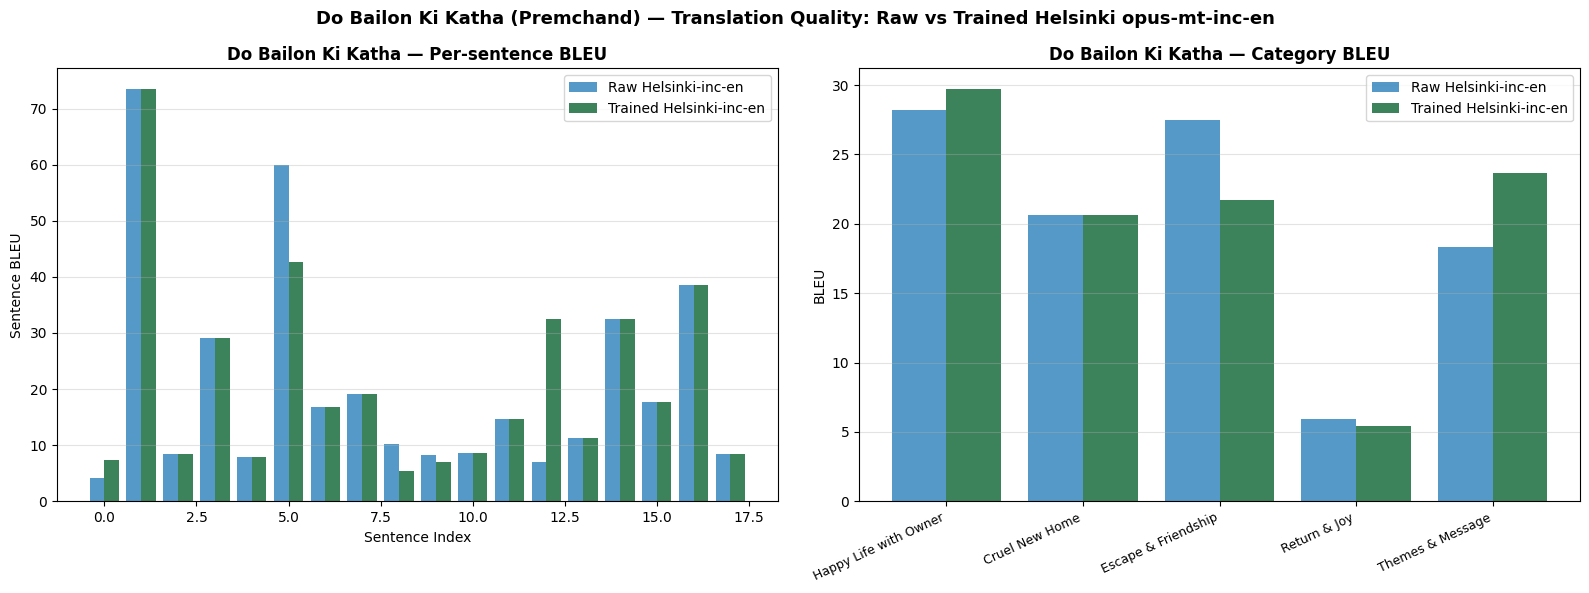


✅ Do Bailon Ki Katha chart displayed & saved -> /kaggle/working/helsinki_inc_samanantar_lm/do_bailon_ki_katha_translation_improvement.png
✅ Pipeline complete! Outputs: /kaggle/working/helsinki_inc_samanantar_lm


In [43]:
# ============================================================
# [18] DO BAILON KI KATHA DEMO — Classic Hindi Literature Translation Test
# ─────────────────────────────────────────────────────────────
# Do Bailon Ki Katha (The Tale of Two Oxen) by Munshi Premchand — Public Domain
# SIDE-BY-SIDE improvement: Raw Helsinki inc-en vs + Samanantar LM
# ============================================================

# ── Plot Summary (shown first) ─────────────────────────────────
print("\n" + "=" * 92)
print(" DO BAILON KI KATHA (दो बैलों की कथा) by Munshi Premchand — Plot Overview")
print("=" * 92)
print("""Do Bailon Ki Katha is a touching story told from the perspective of two loyal oxen, Heera and Moti. 
They live happily with their kind owner Jhuri, working hard in the fields. 
When Jhuri lends them to his brother-in-law for some work, the oxen face cruelty, starvation, and separation threats. 
Their deep friendship and unbreakable bond give them courage to endure hardships and find their way back home. 
Premchand beautifully portrays loyalty, animal intelligence, human greed, and the emotional bond between man and beast through simple yet powerful rural Hindi.""")
print("=" * 92)

DOBAILON_SENTENCES = [
    "हीरा और मोती दोनों बैल झूरी के साथ बहुत खुशी से रहते थे।",
    "वे दोनों एक-दूसरे के सबसे अच्छे दोस्त थे और साथ-साथ काम करते थे।",
    "झूरी उन्हें बहुत प्यार करता था और अच्छा चारा-दाना देता था।",
    "एक दिन झूरी ने अपनी साली के घर बैलों को भेज दिया, जहाँ उनका मालिक बहुत क्रूर था।",
    "वहाँ उन्हें कम चारा मिलता था और बहुत काम करवाया जाता था।",
    "हीरा ने मोती से कहा — यहाँ तो हमारी जान निकल जाएगी, चलो भाग चलें।",
    "दोनों बैल रात में भाग निकले, लेकिन रास्ते में कई मुश्किलें आईं।",
    "वे भूखे-प्यासे थे, फिर भी एक-दूसरे का साथ नहीं छोड़ते थे।",
    "मोती ने कहा — भाई हीरा, चाहे जान चली जाए, लेकिन हम अलग नहीं होंगे।",
    "अंत में दोनों बैल थक-हारकर घर लौट आए और झूरी को देखकर बहुत खुश हुए।",
    "झूरी ने उन्हें देखकर कहा — मेरे बच्चे, तुम वापस आ गए!",
    "प्रेमचंद ने दिखाया कि जानवरों में भी इंसानों जितनी वफादारी और दोस्ती हो सकती है।",
    "गरीब किसान और उसके पशु एक-दूसरे के साथी हैं, दोनों का जीवन संघर्षपूर्ण है।",
    "क्रूरता के सामने भी सच्ची दोस्ती टूट नहीं सकती।",
    "बैलो की कहानी हमें सिखाती है कि प्यार और विश्वास सबसे बड़ी ताकत है।",
    "मनुष्य अक्सर जानवरों से भी कम समझदार साबित होता है।",
    "प्रेमचंद की यह कहानी पशु-प्रेम और ग्रामीण जीवन की मिसाल है।",
    "दो बैलों की वफादारी किसी इंसान से कम नहीं थी।",
]

DOBAILON_REFERENCE = [
    "Heera and Moti, both oxen, lived very happily with Jhuri.",
    "They were the best friends to each other and worked together.",
    "Jhuri loved them dearly and gave them good fodder and grain.",
    "One day Jhuri sent the oxen to his sister-in-law's house, where their owner was very cruel.",
    "There they received little fodder and were made to work very hard.",
    "Heera said to Moti — We will die here, let's run away.",
    "Both oxen escaped at night, but faced many difficulties on the way.",
    "They were hungry and thirsty, yet they did not leave each other's side.",
    "Moti said — Brother Heera, even if we lose our lives, we will not separate.",
    "In the end both oxen returned home tired and exhausted, and were overjoyed to see Jhuri.",
    "Jhuri said on seeing them — My children, you have come back!",
    "Premchand showed that even animals can have loyalty and friendship like humans.",
    "A poor farmer and his animals are companions; both lead a life of struggle.",
    "True friendship cannot break even in the face of cruelty.",
    "The story of the oxen teaches us that love and trust are the greatest strength.",
    "Humans often prove less wise than animals.",
    "This story by Premchand is an example of love for animals and rural life.",
    "The loyalty of the two oxen was no less than that of any human.",
]

# ── Run translations (same beam settings as your original Godaan) ─────
print("\nTranslating Do Bailon Ki Katha sentences (trained model, beam=12)...")
trained_tr = [translate_single(s) for s in DOBAILON_SENTENCES]
print("Translating Do Bailon Ki Katha sentences (raw settings, beam=4)...")
raw_tr = [translate_single(s, n_beams=BEAM_STD) for s in DOBAILON_SENTENCES]

# ── BLEU scores ──────────────────────────────────────────────
g_bleu_raw = round(sacrebleu.corpus_bleu(raw_tr, [DOBAILON_REFERENCE]).score, 2)
g_bleu_trn = round(sacrebleu.corpus_bleu(trained_tr, [DOBAILON_REFERENCE]).score, 2)

# ── Side-by-side display ──────────────────────────────────────
print("\n" + "=" * 92)
print(" DO BAILON KI KATHA — Classic Hindi Literature — Side-by-Side Translation Improvement")
print(f" Raw Helsinki-inc-en BLEU: {g_bleu_raw:.2f} | Trained BLEU: {g_bleu_trn:.2f} | Delta: +{g_bleu_trn-g_bleu_raw:.2f}")
print("=" * 92)

SECTIONS = {
    "Happy Life with Owner": [0, 1, 2],
    "Cruel New Home": [3, 4],
    "Escape & Friendship": [5, 6, 7, 8],
    "Return & Joy": [9, 10],
    "Themes & Message": [11, 12, 13, 14, 15, 16, 17],
}

for sec, idx_list in SECTIONS.items():
    print(f"\n--- {sec} " + "-" * (72 - len(sec)))
    for i in idx_list:
        print(f" [{i+1:02d}] Hindi     : {DOBAILON_SENTENCES[i][:88]}...")
        print(f" Reference : {DOBAILON_REFERENCE[i][:88]}...")
        print(f" Raw       : {raw_tr[i][:88]}...")
        print(f" Trained   : {trained_tr[i][:88]}...")
        print()

# ── Summary ───────────────────────────────────────────────────
print("=" * 92)
print(f" IIT Bombay — Raw : {raw_iit:.2f} | Trained : {trn_iit:.2f} (+{trn_iit-raw_iit:.2f})")
print(f" Do Bailon Ki Katha — Raw : {g_bleu_raw:.2f} | Trained : {g_bleu_trn:.2f} (+{g_bleu_trn-g_bleu_raw:.2f})")
print("=" * 92)

# ── Charts (displayed first) ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

sent_raw = [round(sacrebleu.corpus_bleu([r], [[ref]]).score, 2) for r, ref in zip(raw_tr, DOBAILON_REFERENCE)]
sent_trn = [round(sacrebleu.corpus_bleu([t], [[ref]]).score, 2) for t, ref in zip(trained_tr, DOBAILON_REFERENCE)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xi = np.arange(len(DOBAILON_SENTENCES))
axes[0].bar(xi-0.2, sent_raw, 0.4, label="Raw Helsinki-inc-en", color="#2980b9", alpha=0.8)
axes[0].bar(xi+0.2, sent_trn, 0.4, label="Trained Helsinki-inc-en", color="#1a6d3e", alpha=0.85)
axes[0].set_title("Do Bailon Ki Katha — Per-sentence BLEU", fontweight="bold")
axes[0].set_xlabel("Sentence Index")
axes[0].set_ylabel("Sentence BLEU")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.35)

cat_labels = list(SECTIONS.keys())
c_raw, c_trn = [], []
for sec, idx_list in SECTIONS.items():
    r_h = [raw_tr[i] for i in idx_list]
    t_h = [trained_tr[i] for i in idx_list]
    r_r = [DOBAILON_REFERENCE[i] for i in idx_list]
    c_raw.append(round(sacrebleu.corpus_bleu(r_h, [r_r]).score, 2))
    c_trn.append(round(sacrebleu.corpus_bleu(t_h, [r_r]).score, 2))

xc = np.arange(len(cat_labels))
axes[1].bar(xc-0.2, c_raw, 0.4, label="Raw Helsinki-inc-en", color="#2980b9", alpha=0.8)
axes[1].bar(xc+0.2, c_trn, 0.4, label="Trained Helsinki-inc-en", color="#1a6d3e", alpha=0.85)
axes[1].set_xticks(xc)
axes[1].set_xticklabels(cat_labels, rotation=25, ha='right', fontsize=9)
axes[1].set_title("Do Bailon Ki Katha — Category BLEU", fontweight="bold")
axes[1].set_ylabel("BLEU")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.35)

plt.suptitle("Do Bailon Ki Katha (Premchand) — Translation Quality: Raw vs Trained Helsinki opus-mt-inc-en",
             fontsize=13, fontweight='bold')
plt.tight_layout()

_gchart = os.path.join(OUTPUT_DIR, "do_bailon_ki_katha_translation_improvement.png")
plt.savefig(_gchart, dpi=150, bbox_inches="tight")
plt.show()   # Chart displays first

print(f"\n✅ Do Bailon Ki Katha chart displayed & saved -> {_gchart}")
print("✅ Pipeline complete! Outputs:", OUTPUT_DIR)